In [1]:
import os

import numpy as np
np.set_printoptions(suppress=True)
import pandas as pd
from scipy import stats

from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import (LinearLocator, MultipleLocator, FormatStrFormatter)
from matplotlib.dates import MONDAY
from matplotlib.dates import MonthLocator, WeekdayLocator, DateFormatter
from matplotlib import gridspec
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
%matplotlib inline

print("Package is ready.")

Package is ready.


In [2]:
plt.rcParams['figure.figsize'] = ((8/2.54), (6/2.54))
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.default"] = "rm"
plt.rcParams.update({'font.size': 11})
MARKER_SIZE = 15
cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

plt.rcParams['axes.spines.top'] = False
# plt.rcParams['axes.edgecolor'] = 
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

In [3]:
def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)

In [4]:
SW2_df = pd.read_csv('./results/SW2_greenhouse.csv', index_col='Unnamed: 0')
SW2_df.index = pd.DatetimeIndex(SW2_df.index)

In [5]:
SW2_df = SW2_df.loc['2020-03-05 00:00:00': '2020-07-03 23:59:00']

In [6]:
# SW2_df.index = SW2_df.index.round(freq='1 h') 
# SW2_df = SW2_df.groupby(SW2_df.index).mean()

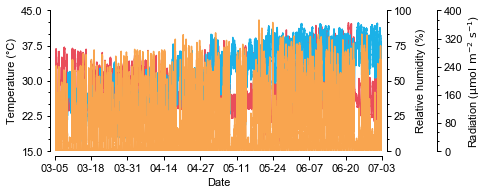

In [7]:
fig = plt.figure(figsize=((8/2.54*2.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.plot(SW2_df.index, SW2_df['temp'], c=cmap[0], zorder=3)

ax1 = ax0.twinx()
ax1.plot(SW2_df.index, SW2_df['hum'], c=cmap[4], zorder=2)

ax2 = ax0.twinx()
ax2.plot(SW2_df.index, SW2_df['rad'], c=cmap[2], zorder=1)

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))
ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_position(('outward', 5))
ax1.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_position(('outward', 55))
ax2.spines['bottom'].set_visible(False)

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(13))
ax0.set_ybound(15, 45)
ax1.yaxis.set_major_locator(LinearLocator(5))
ax1.yaxis.set_minor_locator(LinearLocator(13))
ax1.set_ybound(0, 100)
ax2.yaxis.set_major_locator(LinearLocator(6))
ax2.yaxis.set_minor_locator(LinearLocator(16))
ax2.set_ybound(0, 400)

ax0.set_xlabel('Date')
ax0.set_ylabel('Temperature (°C)')
ax1.set_ylabel('Relative humidity (%)')
ax2.set_ylabel('Radiation (${\mu}mol{\ }m^{-2}{\ }s^{-1}$)')

fig.tight_layout()
fig.savefig('./figures/Fig1-1.svg', transparent=True, format='svg')
#fig.savefig('./figures/Fig1-1.png', transparent=True, dpi=600, format='png')
plt.show() 

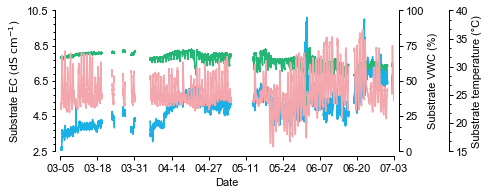

In [8]:
fig = plt.figure(figsize=((8/2.54*2.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.plot(SW2_df.index, SW2_df['subs_EC'], c=cmap[4], zorder=3)

ax1 = ax0.twinx()
ax1.plot(SW2_df.index, SW2_df['subs_VWC'], c=cmap[3], zorder=2)

ax2 = ax0.twinx()
ax2.plot(SW2_df.index, SW2_df['subs_temp'], c=cmap_m[0], zorder=1)

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))
ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_position(('outward', 5))
ax1.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_position(('outward', 55))
ax2.spines['bottom'].set_visible(False)

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(21))
ax0.set_ybound(2.5, 10.5)
ax1.yaxis.set_major_locator(LinearLocator(5))
ax1.yaxis.set_minor_locator(LinearLocator(13))
ax1.set_ybound(0, 100)
ax2.yaxis.set_major_locator(LinearLocator(6))
ax2.yaxis.set_minor_locator(LinearLocator(16))
ax2.set_ybound(15, 40)

ax0.set_xlabel('Date')
ax0.set_ylabel('Substrate EC ($dS{\ }cm^{-1}$)')
ax1.set_ylabel('Substrate VWC (%)')
ax2.set_ylabel('Substrate temperature (°C)')

fig.tight_layout()
fig.savefig('./figures/Fig1-2.svg', transparent=True, format='svg')
#fig.savefig('./figures/Fig1-1.png', transparent=True, dpi=600, format='png')
plt.show() 

## Loadcell weight

### rockwool weight

In [9]:
rockwool = [626, 708, 650, 642]

In [10]:
rockwool_mean = np.mean(rockwool)/1000

In [11]:
np.std(rockwool)

30.963688410782073

### root weight

In [12]:
roots = np.array([301.25, 293.55, 315.15, 356.45, 341.55, 267.65, 303.55, 231.05, 253.05, 272.35, 334.35])/0.1325

In [13]:
np.mean([0.133, 0.137, 0.128, 0.132])

0.1325

In [59]:
np.mean([301.25, 293.55, 315.15, 356.45, 341.55, 267.65, 303.55, 231.05, 253.05, 272.35, 334.35])/4

74.31704545454545

In [14]:
roots_mean = np.mean(roots)/1000

In [15]:
np.std(roots)/1000

0.2793062504826652

In [57]:
roots_mean

2.243533447684391

In [16]:
rockwool_mean + roots_mean

2.900033447684391

In [68]:
weight_df[[_ for _ in weight_df.columns if _.endswith('DW')]].iloc[:, :-1].sum(axis=1)

2020-03-24     15.303333
2020-04-21     99.100000
2020-05-22    173.760000
2020-06-17    245.035000
2020-07-03    262.066000
dtype: float64

In [71]:
np.mean([301.25, 293.55, 315.15, 356.45, 341.55, 267.65, 303.55, 231.05, 253.05, 272.35, 334.35])/4

74.31704545454545

In [72]:
262/74.31704545454545

3.5254361687487576

### water weight

In [17]:
substrate_volume = (120*12*7.5)/1000

In [18]:
substrate_volume

10.8

In [19]:
water_w_df = 10.8*SW2_df['subs_VWC']/100

In [20]:
SW2_df['water'] = water_w_df

In [21]:
SW2_df.head()

,temp,hum,rad,subs_VWC,subs_EC,subs_bulk_EC,subs_temp,permit,loadcell_1,loadcell_2,loadcell_3,water
2020-03-05 00:00:00,25.7000,23.275,-0.851,66.38,2.28,1.13,23.5,43.22,12.32,12.53,12.0,7.16904
2020-03-05 00:01:00,25.6875,23.325,-0.851,66.39,2.30,1.14,23.5,43.24,12.32,12.53,12.0,7.17012
2020-03-05 00:02:00,25.6125,23.525,0.000,66.32,2.29,1.13,23.5,43.16,12.32,12.53,12.0,7.16256
2020-03-05 00:03:00,25.6000,23.450,0.000,66.33,2.29,1.13,23.5,43.18,12.32,12.53,12.0,7.16364
2020-03-05 00:04:00,25.5000,23.550,0.000,66.41,2.29,1.13,23.5,43.25,12.33,12.52,12.0,7.17228


In [22]:
SW2_df.loc[:, 'loadcell_1'] = SW2_df.loc[:, 'loadcell_1'] - rockwool_mean - roots_mean
SW2_df.loc[:, 'loadcell_2'] = SW2_df.loc[:, 'loadcell_2'] - rockwool_mean - roots_mean
SW2_df.loc[:, 'loadcell_3'] = SW2_df.loc[:, 'loadcell_3'] - rockwool_mean - roots_mean

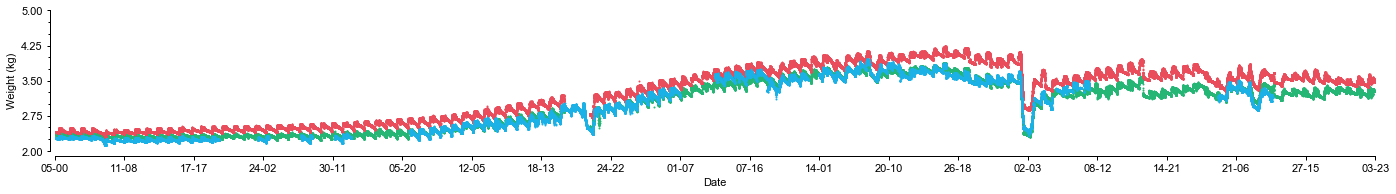

In [23]:
fig = plt.figure(figsize=((8/2.54*6.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(SW2_df.index, SW2_df['loadcell_1']/4, 'o', ms=1, c=cmap[3])
ax0.plot(SW2_df.index, SW2_df['loadcell_2']/4, 'o', ms=1, c=cmap[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_3']/4, 'o', ms=1, c=cmap[4])

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
# ax0.set_xbound(SW2_df.index[1440*115], SW2_df.index[1440*116])
ax0.xaxis.set_major_locator(LinearLocator(20))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%d-%H'))

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(13))
ax0.set_ybound(2, 5)

ax0.set_xlabel('Date')
ax0.set_ylabel('Weight (kg)')

ax0.set_rasterized(True)
fig.tight_layout()
fig.savefig('./figures/Fig2.svg', transparent=True, format='svg')
plt.show() 

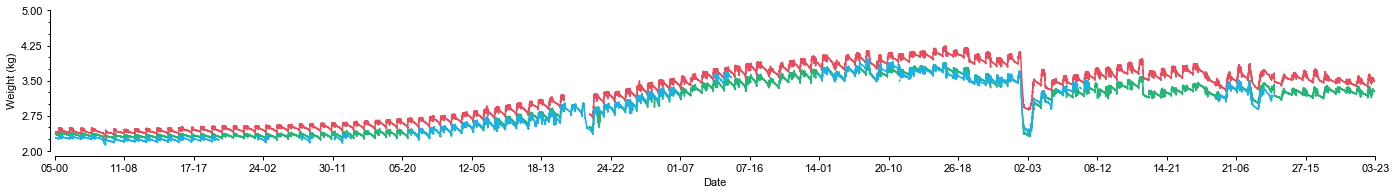

In [24]:
fig = plt.figure(figsize=((8/2.54*6.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(SW2_df.index, SW2_df['loadcell_1']/4, c=cmap[3])
ax0.plot(SW2_df.index, SW2_df['loadcell_2']/4, c=cmap[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_3']/4, c=cmap[4])

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
# ax0.set_xbound(SW2_df.index[1440*115], SW2_df.index[1440*116])
ax0.xaxis.set_major_locator(LinearLocator(20))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%d-%H'))

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(13))
ax0.set_ybound(2, 5)

ax0.set_xlabel('Date')
ax0.set_ylabel('Weight (kg)')

ax0.set_rasterized(True)
fig.tight_layout()
fig.savefig('./figures/Fig2.svg', transparent=True, format='svg')
plt.show() 

In [25]:
for _ in range(2):
    temp_ = []
    for i in range(int(SW2_df.shape[0]/1440)):
        temp = SW2_df['loadcell_1'][1440*i:1440*(i+1)]
        z = abs((temp - temp.mean())/temp.std(ddof=0))
        temp[np.where(z > 3)[0]] = np.nan
        temp_.append(temp)
    SW2_df['loadcell_1'] = pd.concat(temp_).values

    temp_ = []
    for i in range(int(SW2_df.shape[0]/1440)):
        temp = SW2_df['loadcell_2'][1440*i:1440*(i+1)]
        z = abs((temp - temp.mean())/temp.std(ddof=0))
        temp[np.where(z > 3)[0]] = np.nan
        temp_.append(temp)
    SW2_df['loadcell_2'] = pd.concat(temp_).values

    temp_ = []
    for i in range(int(SW2_df.shape[0]/1440)):
        temp = SW2_df['loadcell_3'][1440*i:1440*(i+1)]
        z = abs((temp - temp.mean())/temp.std(ddof=0))
        temp[np.where(z > 3)[0]] = np.nan
        temp_.append(temp)
    SW2_df['loadcell_3'] = pd.concat(temp_).values

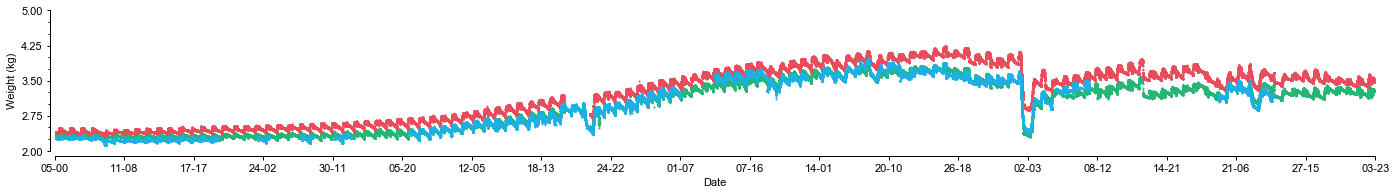

In [26]:
fig = plt.figure(figsize=((8/2.54*6.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(SW2_df.index, SW2_df['loadcell_1']/4, 'o', ms=1, c=cmap[3])
ax0.plot(SW2_df.index, SW2_df['loadcell_2']/4, 'o', ms=1, c=cmap[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_3']/4, 'o', ms=1, c=cmap[4])

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
# ax0.set_xbound(SW2_df.index[1440*115], SW2_df.index[1440*116])
ax0.xaxis.set_major_locator(LinearLocator(20))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%d-%H'))

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(13))
ax0.set_ybound(2, 5)

ax0.set_xlabel('Date')
ax0.set_ylabel('Weight (kg)')

ax0.set_rasterized(True)
fig.tight_layout()
fig.savefig('./figures/Fig2.svg', transparent=True, format='svg')
plt.show() 

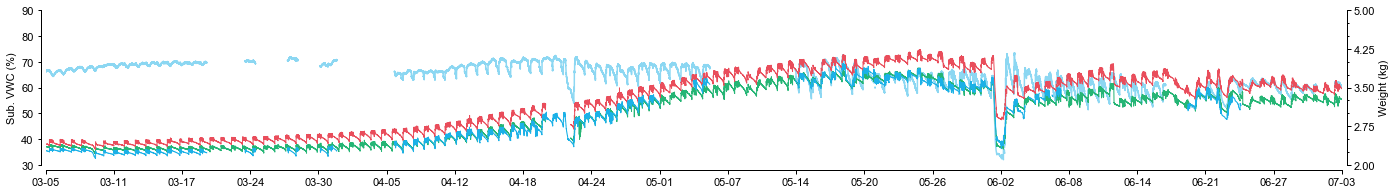

In [27]:
fig = plt.figure(figsize=((8/2.54*6.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(SW2_df.index, SW2_df['subs_VWC'], c=cmap[4], alpha=0.5)

ax1 = ax0.twinx()

ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_position(('outward', 5))
ax1.spines['bottom'].set_visible(False)

ax1.plot(SW2_df.index, SW2_df['subs_VWC'], lw=1, c=cmap[4], alpha=0.5)

ax1.plot(SW2_df.index, SW2_df['loadcell_1']/4, lw=1, c=cmap[3])
ax1.plot(SW2_df.index, SW2_df['loadcell_2']/4, lw=1, c=cmap[0])
ax1.plot(SW2_df.index, SW2_df['loadcell_3']/4, lw=1, c=cmap[4])

ax1.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax1.xaxis.set_major_locator(LinearLocator(20))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax1.yaxis.set_major_locator(LinearLocator(5))
ax1.yaxis.set_minor_locator(LinearLocator(13))
ax1.set_ybound(2, 5)

ax0.set_ybound(30, 90)
ax0.set_ylabel('Sub. VWC (%)')

ax1.set_xlabel('Date')
ax1.set_ylabel('Weight (kg)')

fig.tight_layout()
fig.savefig('./figures/data_check.png', transparent=True, dpi=300, format='png')
plt.show() 

In [28]:
# temp1 = []
# temp2 = []
# temp3 = []
# for i in range(int(SW2_df.shape[0]/1440)):
#     temp1.append(SW2_df.diff(periods=5)[1440*i+360:1440*i+641].max()['loadcell_1'])
#     temp2.append(SW2_df.diff(periods=5)[1440*i+360:1440*i+641].max()['loadcell_2'])
#     temp3.append(SW2_df.diff(periods=5)[1440*i+360:1440*i+641].max()['loadcell_3'])
# first_irr_df = pd.DataFrame(np.concatenate([[temp1], [temp2], [temp3]], axis=0).T, index=pd.date_range('2020-03-05', '2020-07-03') + pd.Timedelta('9h'), columns=['loadcell_1', 'loadcell_2', 'loadcell_3'])

In [29]:
# fig = plt.figure(figsize=((8/2.54*4), (6/2.54*3.2)))
# ax0 = plt.subplot()

# ax0.spines['right'].set_visible(False)
# ax0.spines['left'].set_position(('outward', 5))
# ax0.spines['bottom'].set_position(('outward', 5))

# ax0.plot(SW2_df.index, SW2_df['subs_VWC'], lw=1, c=cmap[4], alpha=0.5)

# ax1 = ax0.twinx()

# ax1.spines['left'].set_visible(False)
# ax1.spines['right'].set_position(('outward', 5))
# ax1.spines['bottom'].set_visible(False)

# ax1.plot(SW2_df.index, SW2_df['loadcell_1']/4, lw=1.5, c=cmap[3], alpha=1)
# ax1.plot(SW2_df.index, SW2_df['loadcell_2']/4, lw=1.5, c=cmap[0], alpha=1)
# ax1.plot(SW2_df.index, SW2_df['loadcell_3']/4, lw=1.5, c=cmap[4], alpha=1)

# ax1.plot(first_irr_df.index, first_irr_df['loadcell_1'], 'o', c='g')
# ax1.plot(first_irr_df.index, first_irr_df['loadcell_2'], 'o', c='r')
# ax1.plot(first_irr_df.index, first_irr_df['loadcell_3'], 'o', c='b')


# i = 5
# # ax1.set_xbound(SW2_df.index.min(), SW2_df.index.max())
# ax1.set_xbound(SW2_df.index[1440*i+600], SW2_df.index[1440*(i+1)-600])
# ax1.xaxis.set_major_locator(LinearLocator(20))
# ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))

# ax1.yaxis.set_major_locator(LinearLocator(15))
# ax1.yaxis.set_minor_locator(LinearLocator(29))
# ax1.set_ybound(2.5, 3.5)

# ax0.set_ybound(64, 70)
# ax0.set_ylabel('Sub. VWC (%)')

# ax1.set_xlabel('Date')
# ax1.set_ylabel('Weight (kg)')

# fig.tight_layout()
# fig.savefig('./figures/data_check.png', transparent=True, dpi=300, format='png')
# plt.show() 

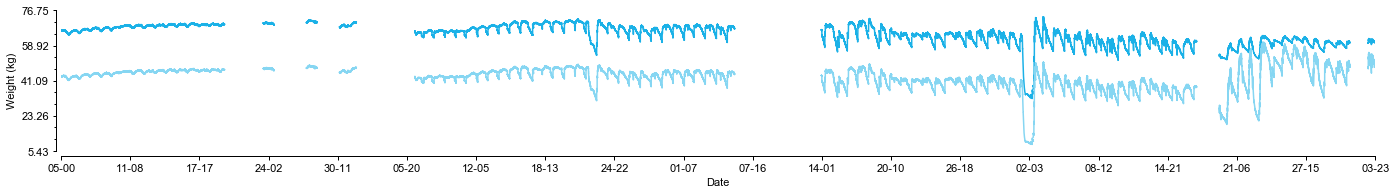

In [30]:
fig = plt.figure(figsize=((8/2.54*6.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(SW2_df.index, SW2_df['subs_VWC'], c=cmap[4])
ax0.plot(SW2_df.index, SW2_df['permit'], c=cmap_m[4])

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(20))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%d-%H'))

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(13))
#ax0.set_ybound(2, 5)

ax0.set_xlabel('Date')
ax0.set_ylabel('Weight (kg)')

ax0.set_rasterized(True)
fig.tight_layout()
fig.savefig('./figures/Fig2.svg', transparent=True, format='svg')
plt.show() 

In [31]:
# SW2_df[SW2_df['loadcell_3'] < 10] = np.nan
# SW2_df[SW2_df['loadcell_3'] > 100] = np.nan

In [32]:
# SW2_df = SW2_df[SW2_df['loadcell_1'] > 11].reindex(SW2_df.index)
# SW2_df = SW2_df[SW2_df['loadcell_1'] < 25].reindex(SW2_df.index)
# SW2_df = SW2_df[SW2_df['loadcell_2'] > 11].reindex(SW2_df.index)
# SW2_df = SW2_df[SW2_df['loadcell_2'] < 25].reindex(SW2_df.index)
# SW2_df = SW2_df[SW2_df['loadcell_3'] > 11].reindex(SW2_df.index)
# SW2_df = SW2_df[SW2_df['loadcell_3'] < 25].reindex(SW2_df.index)

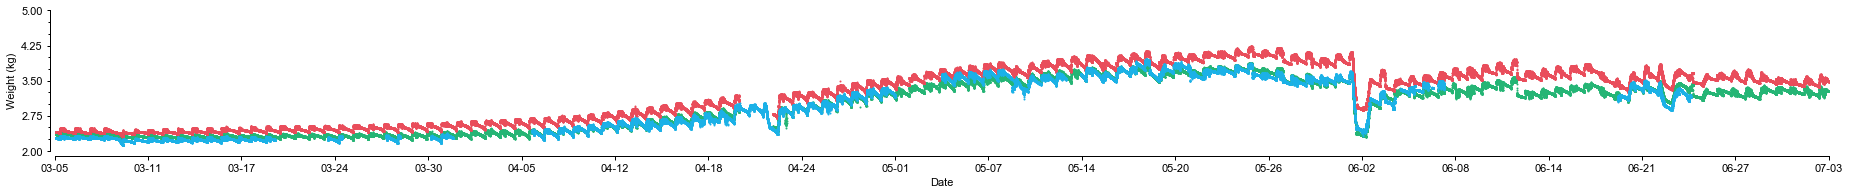

In [33]:
fig = plt.figure(figsize=((8/2.54*8.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(SW2_df.index, SW2_df['loadcell_1']/4, 'o', ms=1, c=cmap[3])
ax0.plot(SW2_df.index, SW2_df['loadcell_2']/4, 'o', ms=1, c=cmap[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_3']/4, 'o', ms=1, c=cmap[4])

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(20))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(13))
ax0.set_ybound(2, 5)

ax0.set_xlabel('Date')
ax0.set_ylabel('Weight (kg)')

ax0.set_rasterized(True)
fig.tight_layout()
fig.savefig('./figures/Fig2.svg', transparent=True, format='svg')
plt.show() 

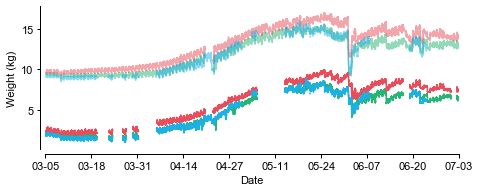

In [34]:
fig = plt.figure(figsize=((8/2.54*2.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(SW2_df.index, SW2_df['loadcell_1'], c=cmap[3], alpha=0.5)
ax0.plot(SW2_df.index, SW2_df['loadcell_2'], c=cmap[0], alpha=0.5)
ax0.plot(SW2_df.index, SW2_df['loadcell_3'], c=cmap[4], alpha=0.5)

ax0.plot(SW2_df.index, SW2_df['loadcell_1'] - SW2_df['water'], c=cmap[3])
ax0.plot(SW2_df.index, SW2_df['loadcell_2'] - SW2_df['water'], c=cmap[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_3'] - SW2_df['water'], c=cmap[4])

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# ax0.yaxis.set_major_locator(LinearLocator(5))
# ax0.yaxis.set_minor_locator(LinearLocator(13))
# ax0.set_ybound(2, 5)

ax0.set_xlabel('Date')
ax0.set_ylabel('Weight (kg)')

fig.tight_layout()
fig.savefig('./figures/Fig2.svg', transparent=True, format='svg')
fig.savefig('./figures/Fig2.png', transparent=True, dpi=600, format='png')
plt.show() 

## Leaf area

In [35]:
leaf_area_df = pd.read_csv('./results/leaf_area.csv', index_col='Unnamed: 0')
leaf_area_df.columns = leaf_area_df.columns.astype('int')

In [36]:
leaf_area_df = leaf_area_df.rename(index={'2020-07-08':'2020-07-07'})
leaf_area_df = leaf_area_df.rename(index={'2020-07-09':'2020-07-07'})

In [37]:
__ = leaf_area_df.loc['2020-07-07'].values.reshape(1,-1)
__ = __[~np.isnan(__)].reshape(1,-1)
__= pd.DataFrame(__, index=['2020-07-07'])

In [38]:
leaf_area_df = leaf_area_df.drop(['2020-07-07'])

In [39]:
leaf_area_df = leaf_area_df.append(__)

In [40]:
leaf_area_df.index = pd.DatetimeIndex(leaf_area_df.index)

In [41]:
leaf_area_df.mean(axis=1)

2020-03-24     2134.356667
2020-04-21     7320.930000
2020-05-22    12664.820000
2020-06-17    15156.470000
2020-07-07    12291.404000
dtype: float64

In [42]:
leaf_area_df.index - pd.datetime(2020, 2, 26)

TimedeltaIndex(['27 days', '55 days', '86 days', '112 days', '132 days'], dtype='timedelta64[ns]', freq=None)

In [43]:
la_er_df = leaf_area_df.sem(axis=1)

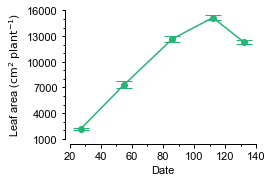

In [44]:
fig = plt.figure(figsize=((8.5/2.54), (6/2.54)))
ax0 = plt.subplot()

x_labels = [27, 55, 86, 112, 132]
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.errorbar(x_labels, leaf_area_df.mean(axis=1), la_er_df,
            linestyle='-', linewidth=1.5, marker='o', capsize=8, elinewidth=1, color=cmap[3])

ax0.set_xbound(20, 140)
ax0.xaxis.set_major_locator(LinearLocator(7))
ax0.xaxis.set_minor_locator(LinearLocator(13))

ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.yaxis.set_minor_locator(LinearLocator(16))
ax0.set_ybound(1000, 16000)

ax0.set_xlabel('Date')
ax0.set_ylabel('Leaf area ($cm^{2}\ plant^{-1}$)')

fig.savefig('./figures/Fig3A.svg', transparent=True, format='svg')

## Destructive weight

In [45]:
weight_df = pd.read_csv('./results/weight.csv', index_col='Unnamed: 0')

In [46]:
weight_df.index = pd.DatetimeIndex(weight_df.index)

In [47]:
wweight_df = weight_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].sum(axis=1)

In [48]:
weight_df.index = np.append(wweight_df.index[:-20], pd.DatetimeIndex(['2020-07-03']*20))

In [49]:
ww_er_df = wweight_df.groupby(wweight_df.index).sem()
ww_df = wweight_df.groupby(wweight_df.index).mean()

In [50]:
w_er_df = weight_df.groupby(weight_df.index).sem()
weight_df = weight_df.groupby(weight_df.index).mean()

In [51]:
SW2_fw_df = SW2_df[SW2_df['rad'] <= 0.2].reindex(SW2_df.index).interpolate()

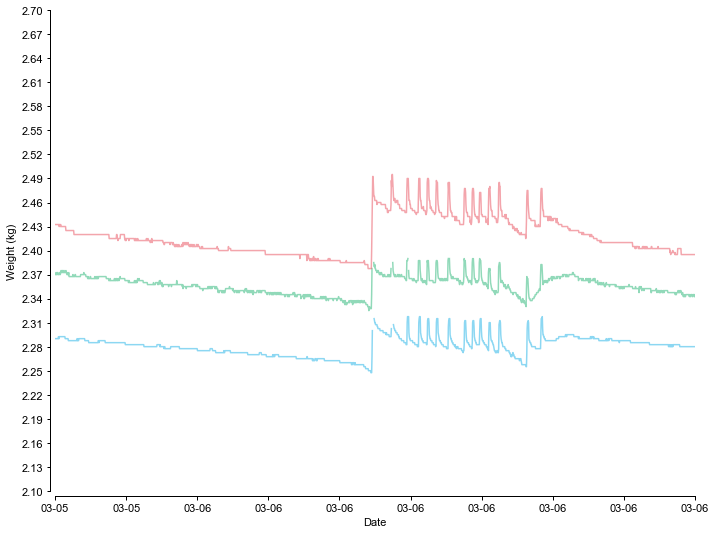

In [52]:
fig = plt.figure(figsize=((8/2.54*3.2), (6/2.54*3.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(SW2_df.index, SW2_df['loadcell_1']/4, c=cmap[3], alpha=0.5)
ax0.plot(SW2_df.index, SW2_df['loadcell_2']/4, c=cmap[0], alpha=0.5)
ax0.plot(SW2_df.index, SW2_df['loadcell_3']/4, c=cmap[4], alpha=0.5)

# ax0.plot(SW2_df.index, (SW2_df['loadcell_1'] - SW2_df['water'])/4, c=cmap[3])
# ax0.plot(SW2_df.index, (SW2_df['loadcell_2'] - SW2_df['water'])/4, c=cmap[0])
# ax0.plot(SW2_df.index, (SW2_df['loadcell_3'] - SW2_df['water'])/4, c=cmap[4])

ax0.plot(SW2_df.index, ((SW2_df[SW2_df['rad'] <= 0.2]['loadcell_1'] - SW2_df['water'])/4).interpolate(), c=cmap[3])
ax0.plot(SW2_df.index, ((SW2_df[SW2_df['rad'] <= 0.2]['loadcell_2'] - SW2_df['water'])/4).interpolate(), c=cmap[0])
ax0.plot(SW2_df.index, ((SW2_df[SW2_df['rad'] <= 0.2]['loadcell_3'] - SW2_df['water'])/4).interpolate(), c=cmap[4])

# ax0.plot(SW2_df.index, ((SW2_fw_df['loadcell_1'] - SW2_df['water'])/4).interpolate(), c=cmap[3])
# ax0.plot(SW2_df.index, ((SW2_fw_df['loadcell_2'] - SW2_df['water'])/4).interpolate(), c=cmap[0])
# ax0.plot(SW2_df.index, ((SW2_fw_df['loadcell_3'] - SW2_df['water'])/4).interpolate(), c=cmap[4])


ax0.plot(wweight_df.index, wweight_df/1000, 'o', c='k')

# ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.set_xbound('2020-03-05 17:40:00', '2020-03-06 23:59:00')
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax0.yaxis.set_major_locator(LinearLocator(21))
# ax0.yaxis.set_minor_locator(LinearLocator(13))
ax0.set_ybound(2.1, 2.7)

ax0.set_xlabel('Date')
ax0.set_ylabel('Weight (kg)')

fig.tight_layout()
fig.savefig('./figures/Fig2.svg', transparent=True, format='svg')
fig.savefig('./figures/Fig2.png', transparent=True, dpi=600, format='png')
plt.show() 

In [56]:
weight_df

,Stem FW,Leaf FW,petiole FW,Fruit count,Idv fruit FW,Plant height,Fruit DW,Leaf DW,Stem DW,petiole DW,Root DW,Root FW
2020-03-24,45.333333,61.333333,13.333333,0.000000,0.000000,50.666667,0.000000,8.916667,5.163333,1.223333,254.905567,1428.991168
2020-04-21,216.000000,246.000000,52.000000,7.000000,462.000000,122.666667,26.420000,38.250000,29.676667,4.753333,292.525000,1538.725754
2020-05-22,342.666667,389.333333,80.666667,7.333333,1017.333333,175.333333,63.456667,51.313333,52.313333,6.676667,264.213900,1267.964472
2020-06-17,513.000000,512.500000,117.500000,11.250000,826.000000,221.500000,62.505000,78.925000,93.225000,10.380000,257.022925,1355.064270
2020-07-03,559.500000,538.400000,132.200000,7.550000,670.250000,207.100000,58.860000,81.988000,108.969500,12.248500,267.520005,1370.463866


In [ ]:
0.06

0시 00분: 0.482732\
7시 39분: 0.459562\
17시 45분: 0.544712\
23시 59분: 0.491172

In [53]:
0.491172 - 0.482732

0.008440000000000003

In [54]:
0.544712 - 0.459562

0.08514999999999995

In [55]:
(0.544712 - 0.459562) - (0.491172 - 0.482732)

0.07670999999999994

밤 동안에 수분이 잎으로 이동한다... 어디서 이동하지? 뿌리에서? 작물안에서 이동하나? 배지에서 가져오나? 야간 증산에 대해 알아봐야할 듯.

일액현상?

In [ ]:
((SW2_df[SW2_df['rad'] <= 0.2]['loadcell_3'] - SW2_df['water'])/4).loc['2020-03-05 17:30:00':'2020-03-05 18:00:00']

In [ ]:
fig = plt.figure(figsize=((8/2.54*2.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(SW2_df.index, SW2_df['loadcell_1']/4, c=cmap[3], alpha=0.5)
ax0.plot(SW2_df.index, SW2_df['loadcell_2']/4, c=cmap[0], alpha=0.5)
ax0.plot(SW2_df.index, SW2_df['loadcell_3']/4, c=cmap[4], alpha=0.5)

ax0.plot(SW2_df.index, (SW2_df['loadcell_1'] - SW2_df['water'])/4, c=cmap[3])
ax0.plot(SW2_df.index, (SW2_df['loadcell_2'] - SW2_df['water'])/4, c=cmap[0])
ax0.plot(SW2_df.index, (SW2_df['loadcell_3'] - SW2_df['water'])/4, c=cmap[4])

ax0.plot(wweight_df.index, wweight_df/1000, 'o', c='k')

# ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.set_xbound('2020-05-22 00:00:00', '2020-05-22 23:59:00')
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# ax0.yaxis.set_major_locator(LinearLocator(5))
# ax0.yaxis.set_minor_locator(LinearLocator(13))
ax0.set_ybound(3.2, 4.5)

ax0.set_xlabel('Date')
ax0.set_ylabel('Weight (kg)')

fig.tight_layout()
plt.show() 

In [ ]:
weight_df.index - pd.datetime(2020, 2, 26)

In [ ]:
for i in range(10):
    fig = plt.figure(figsize=((8.5/2.54), (6/2.54)))
    ax0 = plt.subplot()

    x_labels = [27, 55, 86, 112, 132]
    ax0.spines['right'].set_visible(False)
    ax0.spines['left'].set_position(('outward', 5))
    ax0.spines['bottom'].set_position(('outward', 5))


    ax0.errorbar(x_labels, weight_df.iloc[:, i], w_er_df.iloc[:, i],
                linestyle='-', linewidth=1.5, marker='o', capsize=8, elinewidth=1, color=cmap[3])

    ax0.set_xbound(20, 140)
    ax0.xaxis.set_major_locator(LinearLocator(7))
    ax0.xaxis.set_minor_locator(LinearLocator(13))

    ax0.yaxis.set_major_locator(LinearLocator(6))
    ax0.yaxis.set_minor_locator(LinearLocator(16))
    #ax0.set_ybound(1000, 16000)

    ax0.set_xlabel('Date')
    ax0.set_ylabel(weight_df.columns[i])

    fig.savefig('./figures/Fig3B.svg', transparent=True, format='svg')

In [ ]:
fig = plt.figure(figsize=((8.5/2.54), (6/2.54)))
ax0 = plt.subplot()

x_labels = [27, 55, 86, 112, 132]
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))


ax0.errorbar(x_labels, ww_df, ww_er_df,
            linestyle='-', linewidth=1.5, marker='o', capsize=8, elinewidth=1, color=cmap[3])

ax0.set_xbound(20, 140)
ax0.xaxis.set_major_locator(LinearLocator(7))
ax0.xaxis.set_minor_locator(LinearLocator(13))

ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.yaxis.set_minor_locator(LinearLocator(16))
#ax0.set_ybound(1000, 16000)

ax0.set_xlabel('Date')
ax0.set_ylabel(weight_df.columns[i])

In [ ]:
temp_df = []
for _ in wweight_df.index.unique():
    temp_df.append([wweight_df.loc[_].values.T])

In [ ]:
fig = plt.figure(figsize=((8.5/2.54), (6/2.54)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))


ax0.plot(wweight_df.index, wweight_df, 'o', color=cmap[3])

# ax0.set_xbound(20, 140)
# ax0.xaxis.set_major_locator(LinearLocator(7))
# ax0.xaxis.set_minor_locator(LinearLocator(13))

# ax0.yaxis.set_major_locator(LinearLocator(6))
# ax0.yaxis.set_minor_locator(LinearLocator(16))
# #ax0.set_ybound(1000, 16000)

ax0.set_xlabel('Date')
ax0.set_ylabel(weight_df.columns[i])

In [ ]:
weight_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']]

In [ ]:
harvest_df_l1 = pd.read_excel('./results/loadcell_fruits.xlsx', sheet_name=0, index_col='Unnamed: 0')
harvest_df_l1 = harvest_df_l1.drop(['fruit_num'], axis=1).dropna()
harvest_df_l1.index = pd.DatetimeIndex(harvest_df_l1.index)

harvest_df_l2 = pd.read_excel('./results/loadcell_fruits.xlsx', sheet_name=1, index_col='Unnamed: 0')
harvest_df_l2 = harvest_df_l2.drop(['fruit_num'], axis=1).dropna()
harvest_df_l2.index = pd.DatetimeIndex(harvest_df_l2.index)

harvest_df_l3 = pd.read_excel('./results/loadcell_fruits.xlsx', sheet_name=2, index_col='Unnamed: 0')
harvest_df_l3 = harvest_df_l3.drop(['fruit_num'], axis=1).dropna()
harvest_df_l3.index = pd.DatetimeIndex(harvest_df_l3.index)

In [ ]:
SW2_avg_df = SW2_df.copy()
SW2_avg_df.index = SW2_avg_df.index.round(freq='1 d')
SW2_avg_df = SW2_avg_df.groupby(SW2_avg_df.index).mean()

In [ ]:
harvest_df_l1 = harvest_df_l1.reindex(SW2_avg_df.index).fillna(0)
harvest_df_l2 = harvest_df_l2.reindex(SW2_avg_df.index).fillna(0)
harvest_df_l3 = harvest_df_l3.reindex(SW2_avg_df.index).fillna(0)

In [ ]:
harvest_df_l1 = harvest_df_l1.cumsum()
harvest_df_l2 = harvest_df_l2.cumsum()
harvest_df_l3 = harvest_df_l3.cumsum()

In [ ]:
loadcell_1 = SW2_avg_df['loadcell_1'] + harvest_df_l1['fruit_FW']/1000
loadcell_2 = SW2_avg_df['loadcell_2'] + harvest_df_l2['fruit_FW']/1000
loadcell_3 = SW2_avg_df['loadcell_3'] + harvest_df_l3['fruit_FW']/1000

In [ ]:
fig = plt.figure(figsize=((8/2.54*2.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(SW2_df.index, SW2_df['loadcell_1']/4, c=cmap_m[3])
ax0.plot(SW2_df.index, SW2_df['loadcell_2']/4, c=cmap_m[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_3']/4, c=cmap_m[4])

ax0.plot(SW2_avg_df.index, (loadcell_1 - SW2_avg_df['water'])/4, c=cmap[3])
ax0.plot(SW2_avg_df.index, (loadcell_2 - SW2_avg_df['water'])/4, c=cmap[0])
ax0.plot(SW2_avg_df.index, (loadcell_3 - SW2_avg_df['water'])/4, c=cmap[4])

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
# ax0.set_xbound('2020-06-01', '2020-06-02')
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(13))
#ax0.set_ybound(0, 6)

ax0.set_xlabel('Date')
ax0.set_ylabel('Weight (kg)')

fig.tight_layout()
plt.show() 

In [ ]:
loadcell_1.index = np.arange(8, 130)
loadcell_2.index = np.arange(8, 130)
loadcell_3.index = np.arange(8, 130)
SW2_avg_df.index = np.arange(8, 130)

In [ ]:
stack_cmap = [cmap_m[2], cmap[3], cmap_m[3], cmap[0]]
fig = plt.figure(figsize=((8.5/2.54*4), (6/2.54*2)))
ax0 = plt.subplot()

x_labels = [27, 55, 86, 112, 132]
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))


ax0.stackplot(x_labels, weight_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].T/1000, colors=stack_cmap)

ax0.plot(SW2_avg_df.index, SW2_avg_df['loadcell_1']/4, c=cmap_m[3])
ax0.plot(SW2_avg_df.index, SW2_avg_df['loadcell_2']/4, c=cmap_m[0])
ax0.plot(SW2_avg_df.index, SW2_avg_df['loadcell_3']/4, c=cmap_m[4])

# ax0.plot(SW2_avg_df.index, loadcell_1/4, c=cmap[3])
# ax0.plot(SW2_avg_df.index, loadcell_2/4, c=cmap[0])
# ax0.plot(SW2_avg_df.index, loadcell_3/4, c=cmap[4])

ax0.set_xbound(27, 132)
ax0.xaxis.set_major_locator(LinearLocator(6))
ax0.xaxis.set_minor_locator(LinearLocator(11))

ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.yaxis.set_minor_locator(LinearLocator(11))
ax0.set_ybound(0, 7)

ax0.set_xlabel('DAT')
ax0.set_ylabel('Fresh weight (kg)')

#fig.savefig('./figures/Fig3B.svg', transparent=True, format='svg')

In [ ]:
wweight_df.index = [27]*3 + [55]*3 + [86]*3 + [112]*4 + [132]*20

In [ ]:
wid = 5
ys = weight_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].values/1000
yer = w_er_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].values/1000
fig = plt.figure(figsize=((8.5/2.54), (6/2.54)*2))
ax0 = plt.subplot()

x_labels = [27, 55, 86, 112, 132]
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))


# ax0.bar(x_labels, ys[:, 0], yerr=yer[:, 0], width=wid, capsize=4, color=cmap_m[2])
# ax0.bar(x_labels, ys[:, 1], yerr=yer[:, 1], width=wid, capsize=4, bottom=ys[:, 0], color=cmap[3])
# ax0.bar(x_labels, ys[:, 2], yerr=yer[:, 2], width=wid, capsize=4, bottom=ys[:, 0]+ys[:, 1], color=cmap_m[3])
# ax0.bar(x_labels, ys[:, 3], yerr=yer[:, 3], width=wid, capsize=4, bottom=ys[:, 0]+ys[:, 1]+ys[:, 2], color=cmap[0])
ax0.plot(wweight_df.index, wweight_df/1000, 'o', c='k')

# ax0.plot(SW2_avg_df.index, loadcell_1/4 - 2.7, c=cmap_m[3])
# ax0.plot(SW2_avg_df.index, loadcell_2/4 - 2.7, c=cmap_m[0])
# ax0.plot(SW2_avg_df.index, loadcell_3/4 - 2.7, c=cmap_m[4])

ax0.plot(SW2_avg_df.index, SW2_avg_df['loadcell_1']/4, c=cmap[3])
ax0.plot(SW2_avg_df.index, SW2_avg_df['loadcell_2']/4, c=cmap[0])
ax0.plot(SW2_avg_df.index, SW2_avg_df['loadcell_3']/4, c=cmap[4])

ax0.set_xbound(8, 140)
ax0.xaxis.set_major_locator(LinearLocator(7))
ax0.xaxis.set_minor_locator(LinearLocator(13))

ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.yaxis.set_minor_locator(LinearLocator(11))
ax0.set_ybound(0, 5)

ax0.set_xlabel('DAT')
ax0.set_ylabel('Fresh weight (kg)')

#fig.savefig('./figures/Fig3B.svg', transparent=True, format='svg')


In [ ]:
wid = 5
ys = weight_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].values/1000
yer = w_er_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].values/1000
fig = plt.figure(figsize=((8.5/2.54)*4, (6/2.54)*2))
ax0 = plt.subplot()

x_labels = [27, 55, 86, 112, 132]
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))


# ax0.bar(x_labels, ys[:, 0], yerr=yer[:, 0], width=wid, capsize=4, color=cmap_m[2])
# ax0.bar(x_labels, ys[:, 1], yerr=yer[:, 1], width=wid, capsize=4, bottom=ys[:, 0], color=cmap[3])
# ax0.bar(x_labels, ys[:, 2], yerr=yer[:, 2], width=wid, capsize=4, bottom=ys[:, 0]+ys[:, 1], color=cmap_m[3])
# ax0.bar(x_labels, ys[:, 3], yerr=yer[:, 3], width=wid, capsize=4, bottom=ys[:, 0]+ys[:, 1]+ys[:, 2], color=cmap[0])
ax0.plot(wweight_df.index, wweight_df/1000, 'o', c='k')

# ax0.plot(SW2_avg_df.index, loadcell_1/4 - 2.7, c=cmap_m[3])
# ax0.plot(SW2_avg_df.index, loadcell_2/4 - 2.7, c=cmap_m[0])
# ax0.plot(SW2_avg_df.index, loadcell_3/4 - 2.7, c=cmap_m[4])

ax0.plot(SW2_avg_df.index, (SW2_avg_df['loadcell_1'] - SW2_avg_df['water'])/4, c=cmap[3])
ax0.plot(SW2_avg_df.index, (SW2_avg_df['loadcell_2'] - SW2_avg_df['water'])/4, c=cmap[0])
ax0.plot(SW2_avg_df.index, (SW2_avg_df['loadcell_3'] - SW2_avg_df['water'])/4, c=cmap[4])

ax0.set_xbound(8, 140)
ax0.xaxis.set_major_locator(LinearLocator(7))
ax0.xaxis.set_minor_locator(LinearLocator(13))

ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.yaxis.set_minor_locator(LinearLocator(11))
ax0.set_ybound(0, 3)

ax0.set_xlabel('DAT')
ax0.set_ylabel('Fresh weight (kg)')

#fig.savefig('./figures/Fig3B.svg', transparent=True, format='svg')


물 무게가 초반에는 2.3키로, 후반에는 1.8키로 미만? 그런가...? VWC?

In [ ]:
water_df = pd.DataFrame([9, 5], index=[8, 129], columns=['water']).reindex(SW2_avg_df.index).interpolate()

## SPAD

In [ ]:
spad_df = pd.read_excel('./data/nondestructive/SPAD.xlsx', index_col='Unnamed: 0')

In [ ]:
spad_df.index - pd.datetime(2020, 2, 26)

In [ ]:
spad_df.columns = ['SPAD_l', 'SPAD_l', 'SPAD_l', 'SPAD_m', 'SPAD_m', 'SPAD_m', 'SPAD_u', 'SPAD_u', 'SPAD_u']

In [ ]:
spad_er_df = spad_df.groupby(spad_df.columns, axis=1).sem()
spad_df = spad_df.groupby(spad_df.columns, axis=1).mean()

In [ ]:
fig = plt.figure(figsize=((8.5/2.54)*2, (6/2.54)))
ax0 = plt.subplot()

x_labels = [27, 48, 49, 51, 54, 56, 58, 61, 63, 65, 68, 71, 72, 75, 77, 84, 86, 90, 91, 93, 96, 98, 100, 103, 107, 112, 114, 119, 121, 124, 126]
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.errorbar(x_labels, spad_df['SPAD_l'], spad_er_df['SPAD_l'],
            linestyle='-', linewidth=1.5, marker='o', mec='k', mew=0.5, capsize=4, elinewidth=1, color=cmap[3])
ax0.errorbar(x_labels, spad_df['SPAD_m'], spad_er_df['SPAD_m'],
            linestyle='-', linewidth=1.5, marker='o', mec='k', mew=0.5, capsize=4, elinewidth=1, color=cmap[4])
ax0.errorbar(x_labels, spad_df['SPAD_u'], spad_er_df['SPAD_u'],
            linestyle='-', linewidth=1.5, marker='o', mec='k', mew=0.5, capsize=4, elinewidth=1, color=cmap[0])

ax0.set_xbound(20, 140)
ax0.xaxis.set_major_locator(LinearLocator(7))
ax0.xaxis.set_minor_locator(LinearLocator(13))

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(9))
ax0.set_ybound(40, 80)

ax0.set_xlabel('Date')
ax0.set_ylabel('SPAD')

fig.savefig('./figures/Fig3C.svg', transparent=True, format='svg')

## DISUSE

SW2_df.index = SW2_df.index.round(freq='1 d')
SW2_df = SW2_df.groupby(SW2_df.index).mean()

SW2_df.index = np.arange(8, 136)

stack_cmap = [cmap[2], cmap_m[2], cmap[3], cmap_m[3], cmap[0]]
fig = plt.figure(figsize=((8.5/2.54), (6/2.54)))
ax0 = plt.subplot()

x_labels = [27, 55, 86, 112, 132]
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))


ax0.stackplot(x_labels, weight_df[['Root FW', 'Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].T/1000, colors=stack_cmap)
ax0.plot(SW2_df.index, SW2_df['loadcell_1']/4, c=cmap[3])
ax0.plot(SW2_df.index, SW2_df['loadcell_2']/4, c=cmap[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_3']/4, c=cmap[4])

ax0.set_xbound(27, 132)
ax0.xaxis.set_major_locator(LinearLocator(6))
ax0.xaxis.set_minor_locator(LinearLocator(11))

ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.yaxis.set_minor_locator(LinearLocator(11))
ax0.set_ybound(0, 5)

ax0.set_xlabel('DAT')
ax0.set_ylabel('Fresh weight (kg)')

#fig.savefig('./figures/Fig3B.svg', transparent=True, format='svg')

wid = 15
ys = weight_df[['Root FW', 'Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].values/1000
yer = w_er_df[['Root FW', 'Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].values/1000
fig = plt.figure(figsize=((8.5/2.54), (6/2.54)))
ax0 = plt.subplot()

x_labels = [27, 55, 86, 112, 132]
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))


ax0.bar(x_labels, ys[:, 0], yerr=yer[:, 0], width=wid, capsize=4, color=cmap[2])
ax0.bar(x_labels, ys[:, 1], yerr=yer[:, 1], width=wid, capsize=4, bottom=ys[:, 0], color=cmap_m[2])
ax0.bar(x_labels, ys[:, 2], yerr=yer[:, 2], width=wid, capsize=4, bottom=ys[:, 0]+ys[:, 1], color=cmap[3])
ax0.bar(x_labels, ys[:, 3], yerr=yer[:, 3], width=wid, capsize=4, bottom=ys[:, 0]+ys[:, 1]+ys[:, 2], color=cmap_m[3])
ax0.bar(x_labels, ys[:, 4], yerr=yer[:, 4], width=wid, capsize=4, bottom=ys[:, 0]+ys[:, 1]+ys[:, 2]+ys[:, 3], color=cmap[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_1']/4, c=cmap[3])
ax0.plot(SW2_df.index, SW2_df['loadcell_2']/4, c=cmap[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_3']/4, c=cmap[4])

ax0.set_xbound(20, 140)
ax0.xaxis.set_major_locator(LinearLocator(7))
ax0.xaxis.set_minor_locator(LinearLocator(13))

ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.yaxis.set_minor_locator(LinearLocator(11))
ax0.set_ybound(0, 5)

ax0.set_xlabel('DAT')
ax0.set_ylabel('Fresh weight (kg)')

#fig.savefig('./figures/Fig3B.svg', transparent=True, format='svg')
